In [41]:
import numpy as np
import tensorflow as tf 
from tensorflow.keras.layers import Conv2D, LeakyReLU, Concatenate, Add, Input
import cv2
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

1/1 [==============================] - 0s 40ms/step
(1, 128, 128, 8)


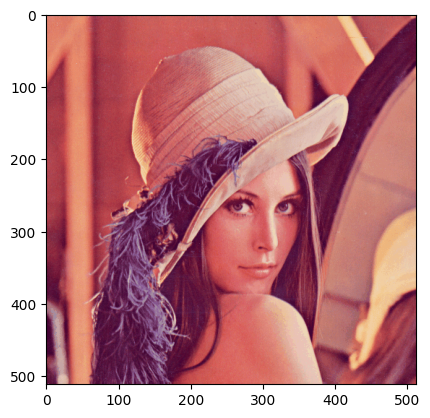

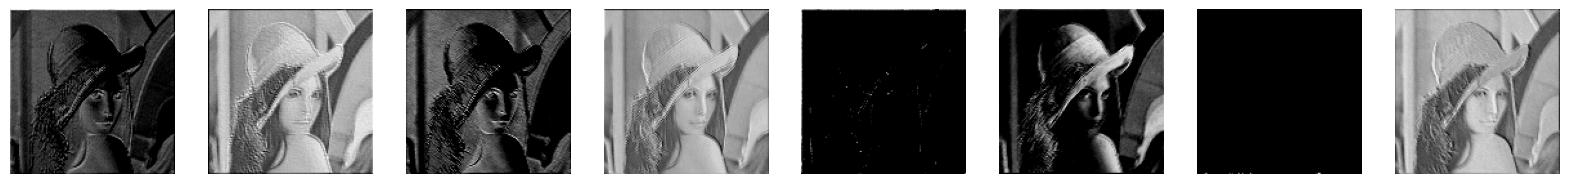

In [39]:
im_path ="E:\complete_python\images\lenna.bmp"
inp =Image.open(im_path)
plt.imshow(inp)

img = image.load_img(im_path, target_size=(128, 128))
img_array =image.img_to_array(img) /255.0
img_array =np.expand_dims(img_array,axis=0)

input  = Input(shape=(128,128,3) ) 

x1= Conv2D(8, kernel_size =(3,3), padding ='same')(input)
x2= ReLU()(x1)
model=Model(inputs=input, outputs=x2)
output = model.predict(img_array)

print(output.shape)

fig, axs = plt.subplots(1, 8, figsize=(20, 5))
for i in range(8):
    axs[i].imshow(output[0, :, :, i], cmap='gray')
    axs[i].axis('off')
plt.show()


1/1 [==============================] - 2s 2s/step
Output shape: (1, 128, 128, 64)


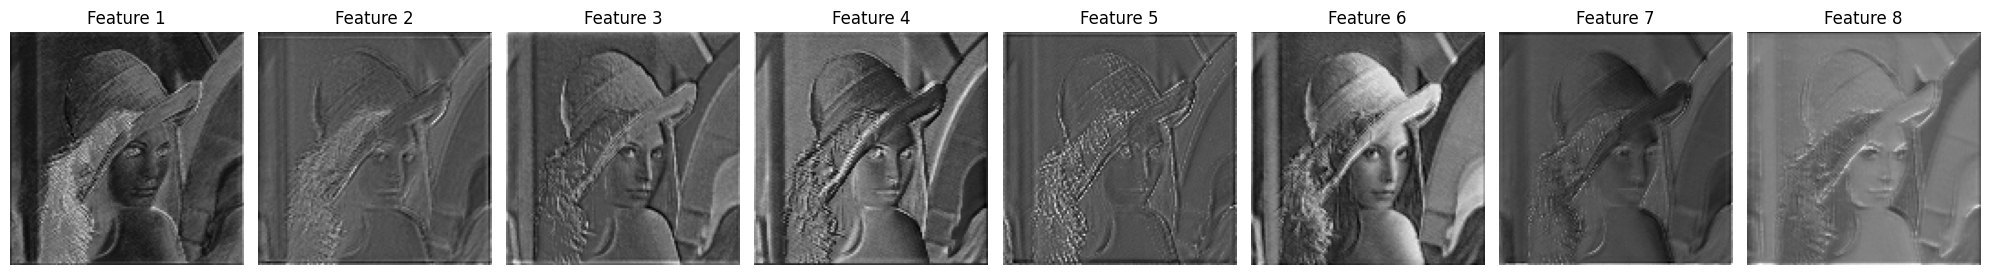

In [ ]:

def dense_block(x, filters=64, kernel_size=3):
    inputs = [x]
    for i in range(4): # 4 conv for each dense block 
        x_concat = Concatenate()(inputs)
        out = Conv2D(filters, kernel_size, padding='same')(x_concat)
        out = LeakyReLU(alpha=0.2)(out)
        inputs.append(out)
    x_out = Concatenate()(inputs)
    return x_out

def RRDB(x, filters=64, scaling=0.2):
    residual = x
    for _ in range(3):  # 3 dense in each rrdb
        x = dense_block(x, filters)
    x = Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.Lambda(lambda t: t * scaling)(x)
    return Add()([residual, x])



input_tensor = Input(shape=(128, 128, 3))


f0 = Conv2D(64, kernel_size=3, padding='same')(input_tensor)
f0 = LeakyReLU(alpha=0.2)(f0)


x = f0
for _ in range(3):  # 3 RRDB blocks
    x = RRDB(x, filters=64)

# Define model
model = Model(inputs=input_tensor, outputs=x)


output = model.predict(img_array)
print("Output shape:", output.shape) 


fig, axs = plt.subplots(1, 8, figsize=(20, 5))
for i in range(8):
    axs[i].imshow(output[0, :, :, i], cmap='gray')
    axs[i].set_title(f'Feature {i+1}')
    axs[i].axis('off')
plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 34ms/step


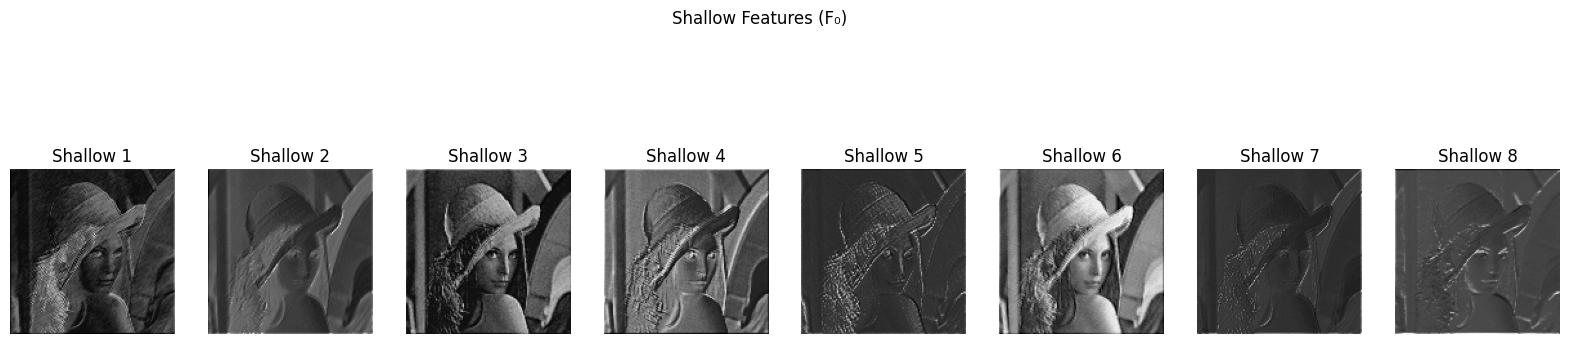

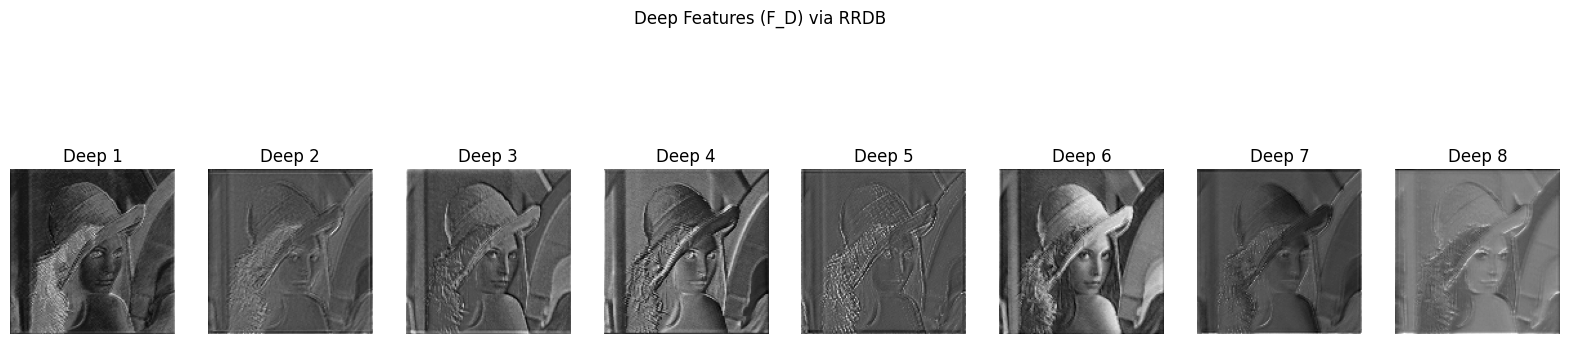

In [44]:
shallow_model = Model(inputs=model.input, outputs=f0)
shallow_output = shallow_model.predict(img_array)

# Plot first 8 shallow features
fig, axs = plt.subplots(1, 8, figsize=(20, 5))
for i in range(8):
    axs[i].imshow(shallow_output[0, :, :, i], cmap='gray')
    axs[i].set_title(f'Shallow {i+1}')
    axs[i].axis('off')
plt.suptitle("Shallow Features (F₀)")
plt.show()
# Plot first 8 deep features
fig, axs = plt.subplots(1, 8, figsize=(20, 5))
for i in range(8):
    axs[i].imshow(output[0, :, :, i], cmap='gray')
    axs[i].set_title(f'Deep {i+1}')
    axs[i].axis('off')
plt.suptitle("Deep Features (F_D) via RRDB")
plt.show()


1/1 [==============================] - 2s 2s/step
Output shape after Transformer block: (1, 64, 64, 64)


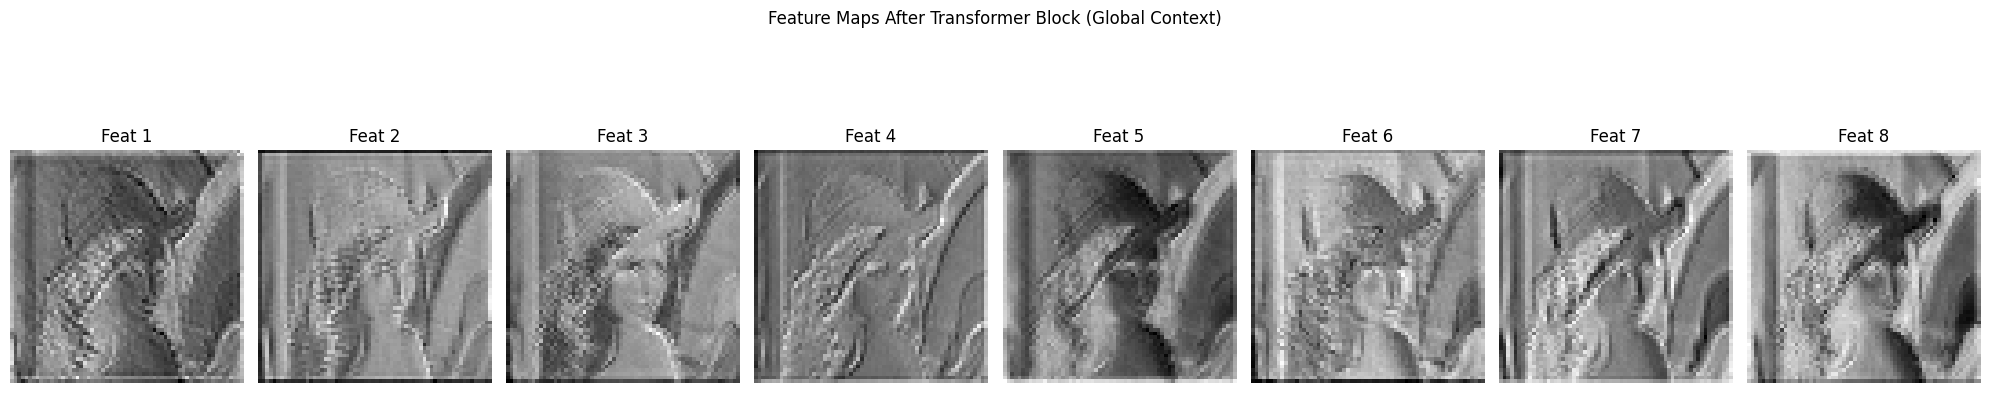

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, LeakyReLU, Add, Concatenate, LayerNormalization, MultiHeadAttention, Dense, Reshape, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


img_path = "E:/complete_python/images/lenna.bmp"
img = image.load_img(img_path, target_size=(64, 64))
img_array = np.expand_dims(image.img_to_array(img) / 255.0, axis=0)  

# rrdb
def dense_block(x, filters=64):
    inputs = [x]
    for i in range(4):
        x_concat = Concatenate()(inputs)
        out = Conv2D(filters, 3, padding='same')(x_concat)
        out = LeakyReLU(alpha=0.2)(out)
        inputs.append(out)
    return Concatenate()(inputs)

def RRDB(x, filters=64, scaling=0.2):
    residual = x
    for _ in range(3):
        x = dense_block(x, filters)
    x = Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.Lambda(lambda t: t * scaling)(x)
    return Add()([residual, x])

# trasformer
def transformer_block(x, num_heads=4, mlp_dim=128):
    B, H, W, C = x.shape
    x_flat = Reshape((H*W, C))(x)  # [B, N, C]
    
    
    norm1 = LayerNormalization()(x_flat)
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=C//num_heads)(norm1, norm1)
    x_res1 = Add()([x_flat, attn_output])


    norm2 = LayerNormalization()(x_res1)
    mlp_output = Dense(mlp_dim, activation='relu')(norm2)
    mlp_output = Dense(C)(mlp_output)
    x_out = Add()([x_res1, mlp_output])

    return Reshape((H, W, C))(x_out)  #


# full 
input_tensor = Input(shape=(64, 64, 3))
f0 = Conv2D(64, 3, padding='same')(input_tensor)
f0 = LeakyReLU(alpha=0.2)(f0)

# 3  RRDB 
x = f0
for _ in range(3):
    x = RRDB(x, filters=64)

#  Transformer  for global modeling
x = transformer_block(x, num_heads=4, mlp_dim=64)


model = Model(inputs=input_tensor, outputs=x)
output = model.predict(img_array)

print("Output shape after Transformer block:", output.shape)  


fig, axs = plt.subplots(1, 8, figsize=(20, 5))
for i in range(8):
    axs[i].imshow(output[0, :, :, i], cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f'Feat {i+1}')
plt.suptitle("Feature Maps After Transformer Block (Global Context)")
plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 62ms/step


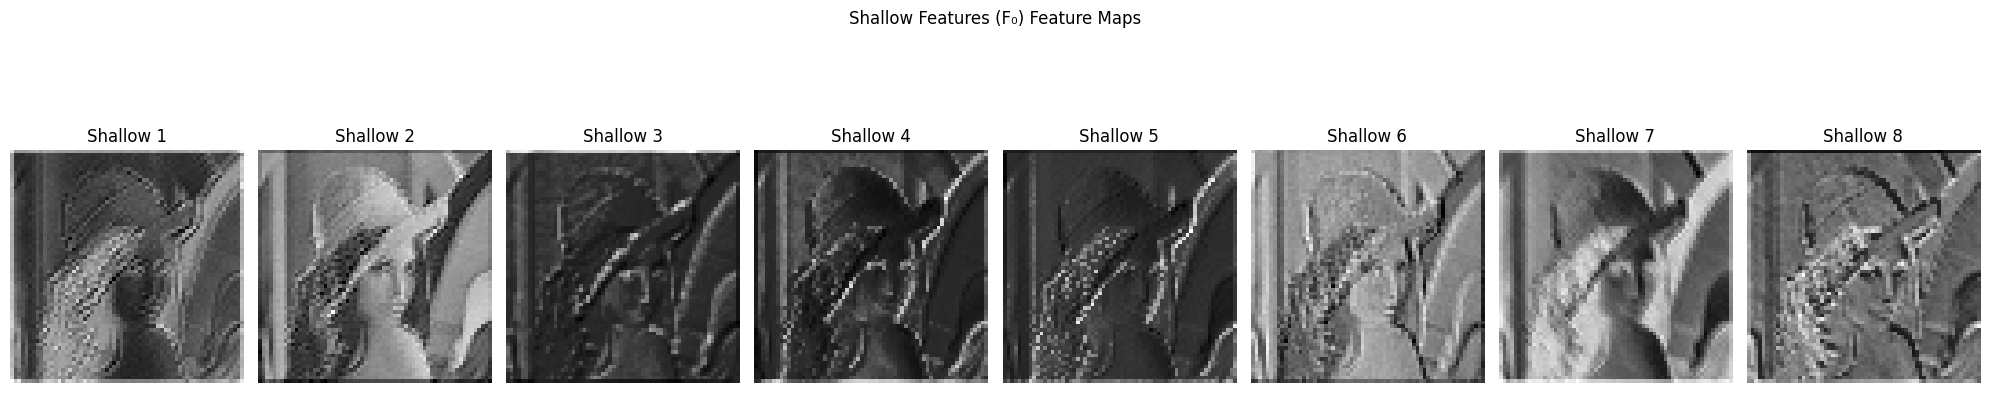

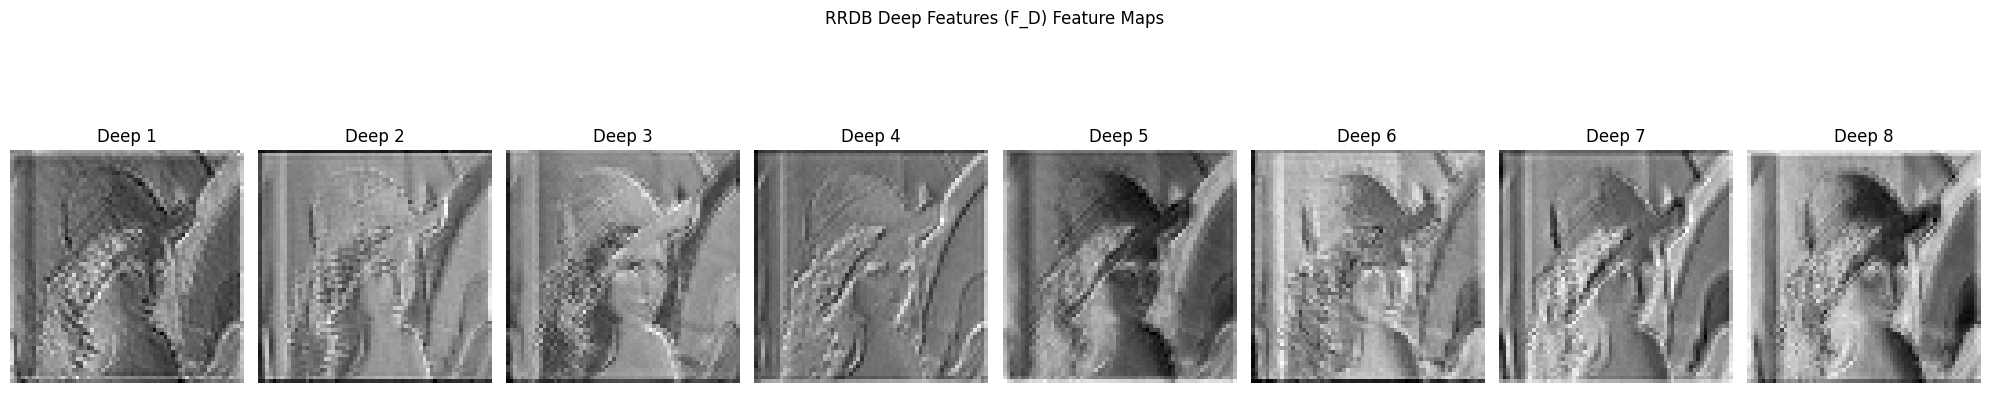

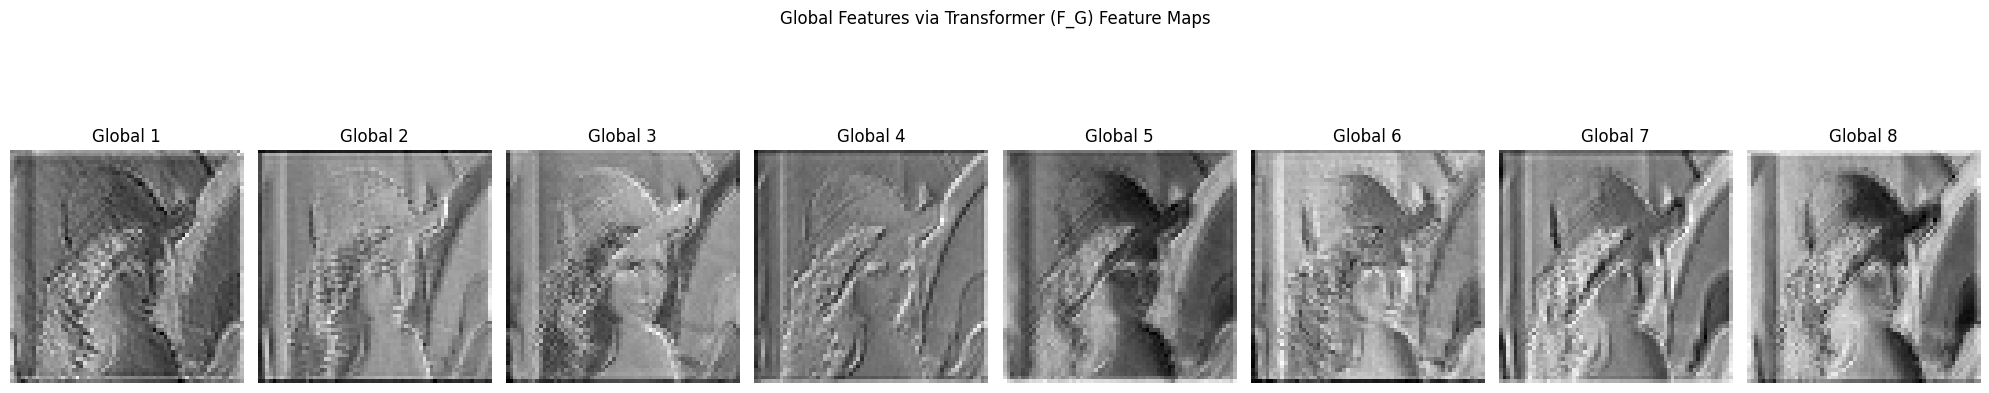

In [52]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Shallow Features 
shallow_model = Model(inputs=model.input, outputs=f0)
shallow_output = shallow_model.predict(img_array)

# Deep Features
rrdb_model = Model(inputs=model.input, outputs=x)  
deep_output = rrdb_model.predict(img_array)

# Global Context 
global_output = model.predict(img_array)



def plot_feature_maps(feature_tensor, title_prefix, stage_name):
    fig, axs = plt.subplots(1, 8, figsize=(20, 5))
    for i in range(8):
        axs[i].imshow(feature_tensor[0, :, :, i], cmap='gray')
        axs[i].set_title(f'{title_prefix} {i+1}')
        axs[i].axis('off')
    plt.suptitle(f"{stage_name} Feature Maps")
    plt.tight_layout()
    plt.show()


plot_feature_maps(shallow_output, "Shallow", "Shallow Features (F₀)")
plot_feature_maps(deep_output, "Deep", "RRDB Deep Features (F_D)")
plot_feature_maps(global_output, "Global", "Global Features via Transformer (F_G)")


1/1 [==============================] - 0s 273ms/step


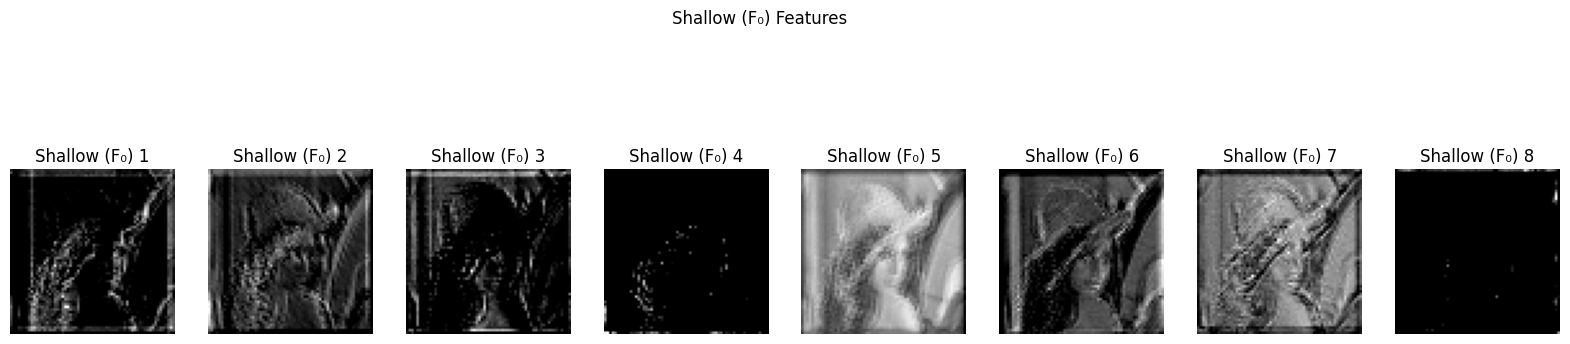

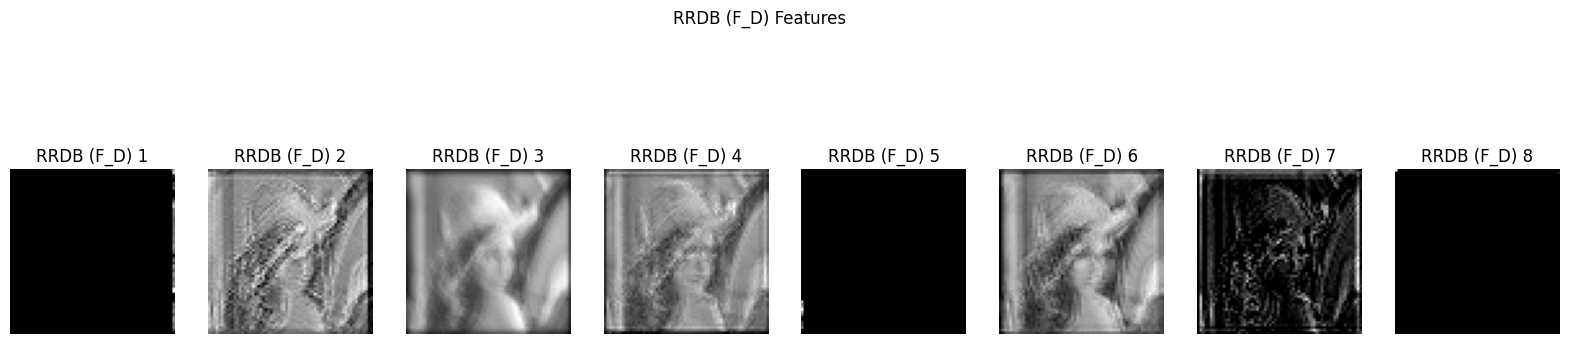

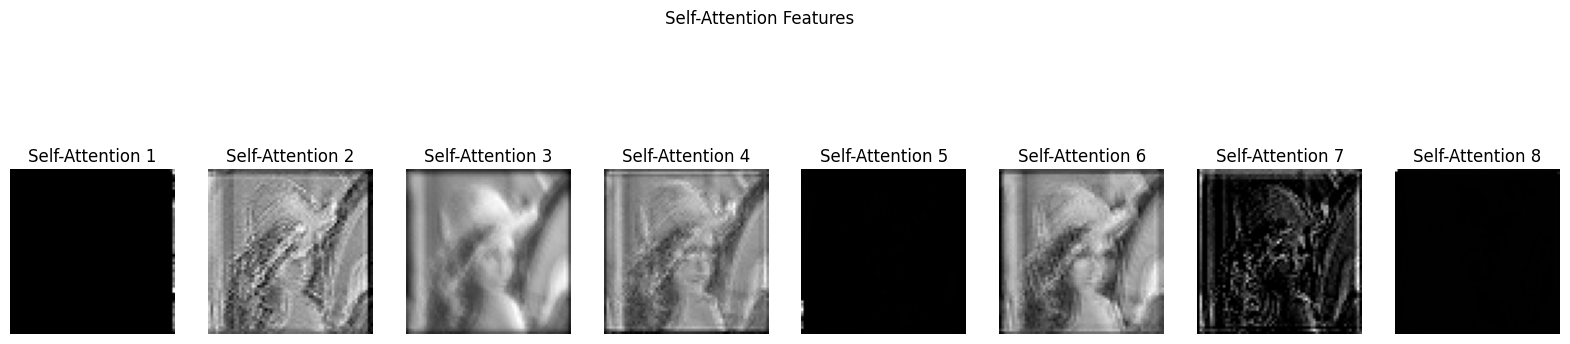

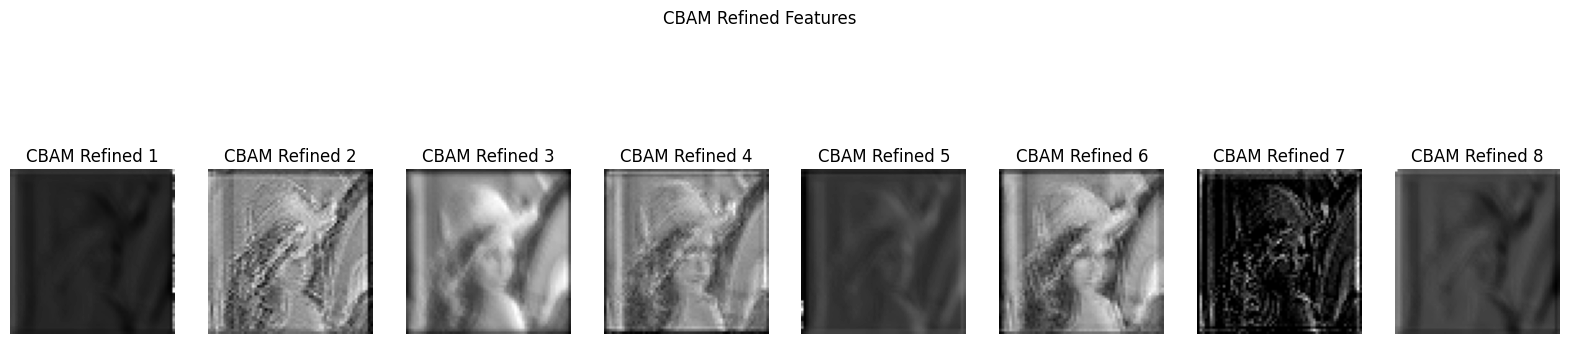

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg19 import preprocess_input

#  CBAM  
def cbam_block(input_tensor, reduction_ratio=8):
    # Channel Attention
    channel = input_tensor.shape[-1]
    avg_pool = layers.GlobalAveragePooling2D()(input_tensor)
    max_pool = layers.GlobalMaxPooling2D()(input_tensor)
    shared_dense_one = layers.Dense(channel // reduction_ratio, activation='relu')
    shared_dense_two = layers.Dense(channel)

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))

    ca = layers.Add()([avg_out, max_out])
    ca = layers.Activation('sigmoid')(ca)
    ca = layers.Reshape((1, 1, channel))(ca)
    channel_refined = layers.Multiply()([input_tensor, ca])

    # Spatial Attention
    avg_pool = tf.reduce_mean(channel_refined, axis=-1, keepdims=True)
    max_pool = tf.reduce_max(channel_refined, axis=-1, keepdims=True)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    sa = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    refined = layers.Multiply()([channel_refined, sa])
    return refined

# Attention Block
def self_attention_2d(x):
    filters = x.shape[-1]
    f = layers.Conv2D(filters // 8, kernel_size=1)(x)
    g = layers.Conv2D(filters // 8, kernel_size=1)(x)
    h = layers.Conv2D(filters, kernel_size=1)(x)

    f_flat = tf.reshape(f, [tf.shape(f)[0], -1, f.shape[-1]])
    g_flat = tf.reshape(g, [tf.shape(g)[0], -1, g.shape[-1]])
    h_flat = tf.reshape(h, [tf.shape(h)[0], -1, h.shape[-1]])

    beta = tf.nn.softmax(tf.matmul(f_flat, g_flat, transpose_b=True), axis=-1)
    o = tf.matmul(beta, h_flat)
    o = tf.reshape(o, tf.shape(x))
    o = layers.Conv2D(filters, 1, padding='same')(o)
    return layers.Add()([x, o])

# --------- Shallow 
def shallow_feature_extractor(input_tensor):
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(input_tensor)
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    return x


input_img = Input(shape=(64, 64, 3))
f0 = shallow_feature_extractor(input_img)  

#  RRDB
rrdb_output = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(f0)

# Transformer block 
transformer_output = self_attention_2d(rrdb_output)


cbam_output = cbam_block(transformer_output)


model = Model(inputs=input_img, outputs=cbam_output)


def load_image(path, target_size=(64, 64)):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return np.expand_dims(img_array, axis=0)


#in img 

shallow_model = Model(inputs=model.input, outputs=f0)
rrdb_model = Model(inputs=model.input, outputs=rrdb_output)
transformer_model = Model(inputs=model.input, outputs=transformer_output)
cbam_model = Model(inputs=model.input, outputs=cbam_output)

shallow_output = shallow_model.predict(img_array)
rrdb_output_v = rrdb_model.predict(img_array)
transformer_output_v = transformer_model.predict(img_array)
cbam_output_v = cbam_model.predict(img_array)


def plot_features(features, title):
    fig, axs = plt.subplots(1, 8, figsize=(20, 5))
    for i in range(8):
        axs[i].imshow(features[0, :, :, i], cmap='gray')
        axs[i].set_title(f'{title} {i+1}')
        axs[i].axis('off')
    plt.suptitle(f"{title} Features")
    plt.show()

plot_features(shallow_output, "Shallow (F₀)")
plot_features(rrdb_output_v, "RRDB (F_D)")
plot_features(transformer_output_v, "Self-Attention")
plot_features(cbam_output_v, "CBAM Refined")


Model: "model_35"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_18 (InputLayer)          [(None, 64, 64, 3)]  0           []                               
                                                                                                  
 conv2d_294 (Conv2D)            (None, 64, 64, 64)   1792        ['input_18[0][0]']               
                                                                                                  
 conv2d_295 (Conv2D)            (None, 64, 64, 64)   36928       ['conv2d_294[0][0]']             
                                                                                                  
 conv2d_296 (Conv2D)            (None, 64, 64, 64)   36928       ['conv2d_295[0][0]']             
                                                                                           

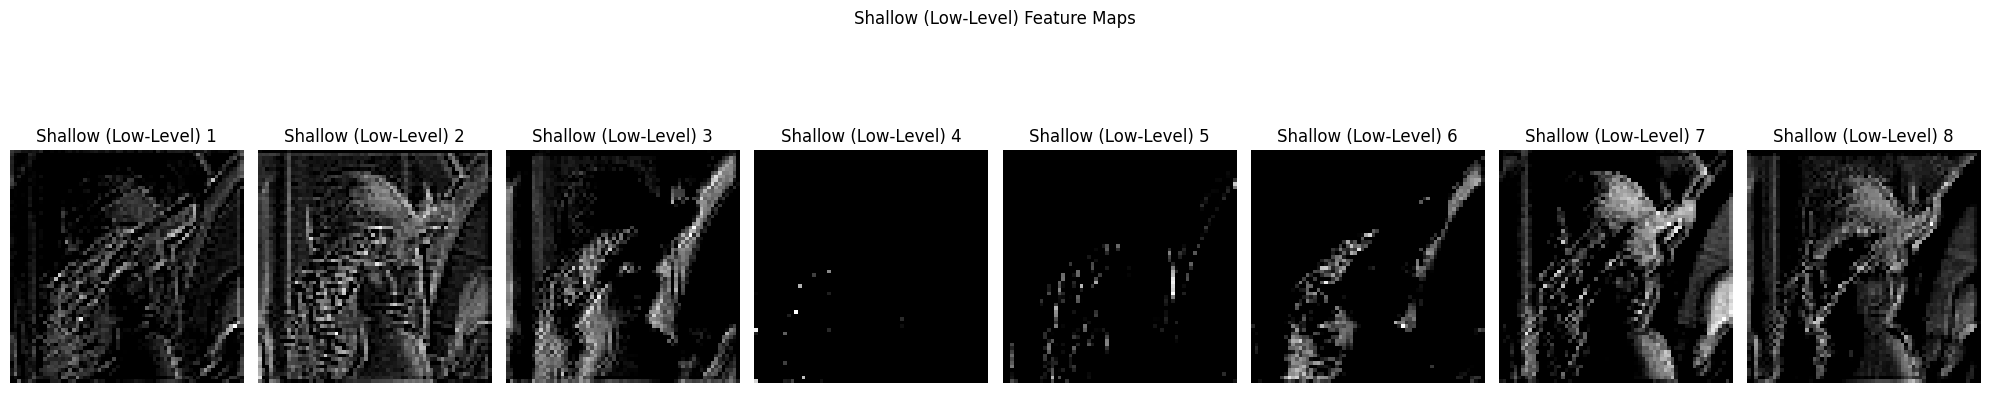

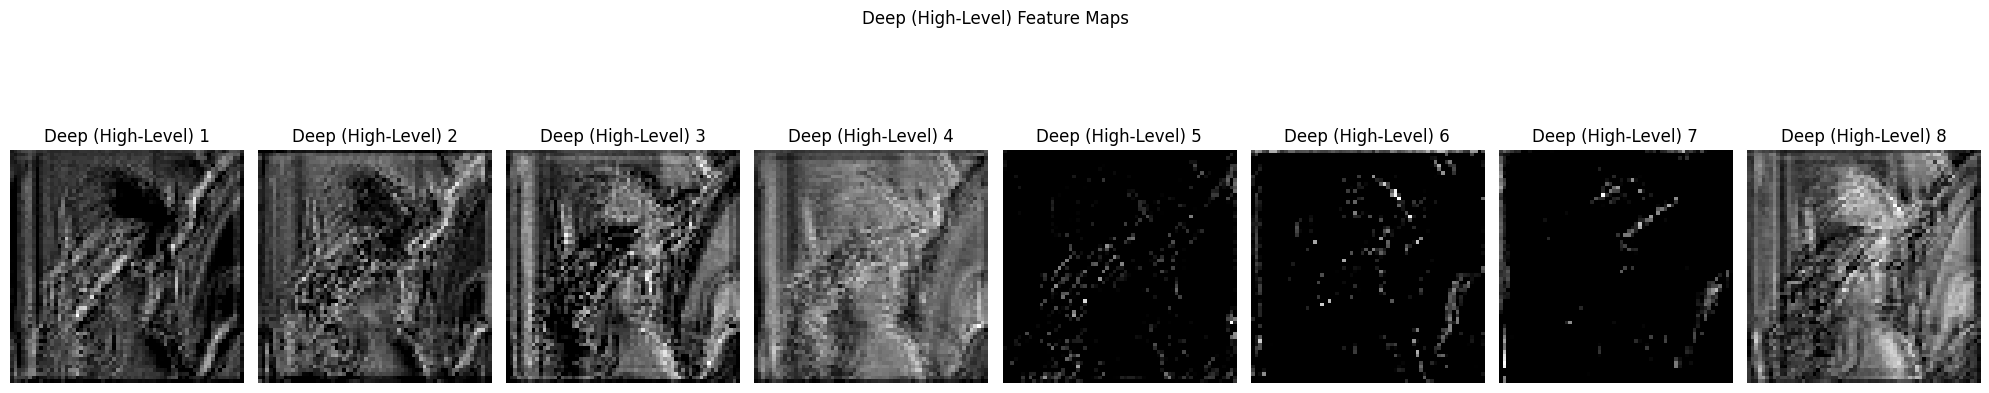

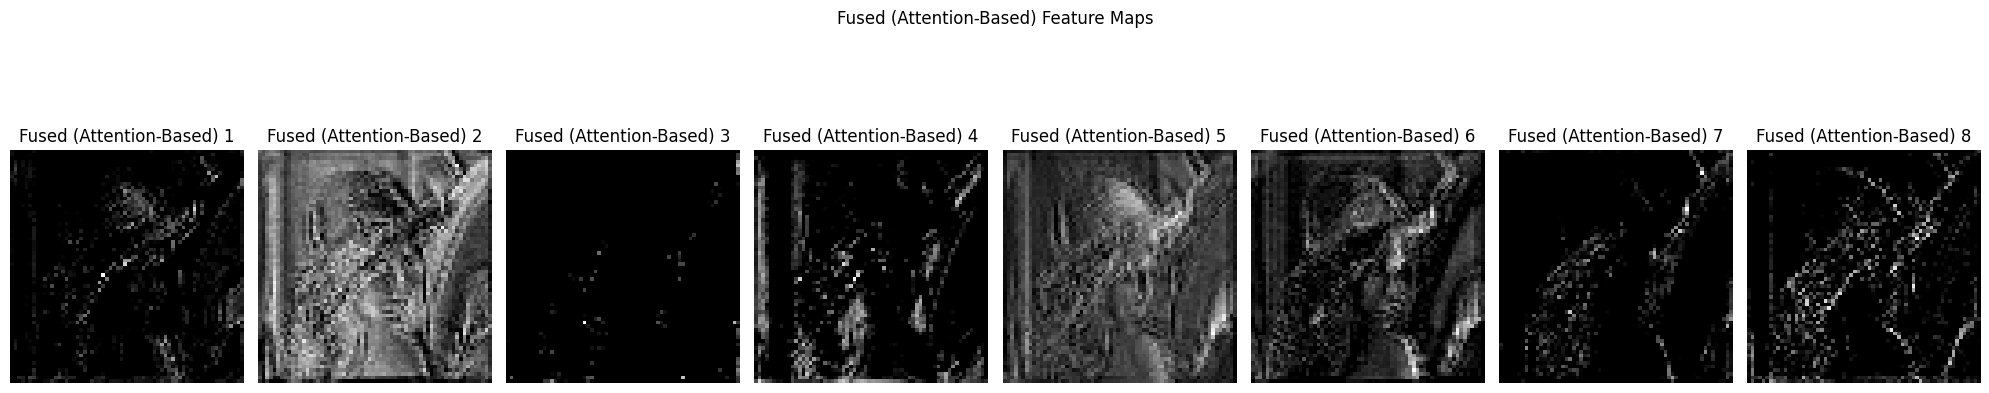

In [63]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array


# Attention Feature Fusion 

def attention_fusion_module(high_feat, low_feat, filters=64):
    high_proj = layers.Conv2D(filters, kernel_size=1, padding='same', activation='relu')(high_feat)
    low_proj = layers.Conv2D(filters, kernel_size=1, padding='same', activation='relu')(low_feat)
    
    fusion = layers.Concatenate()([high_proj, low_proj])
    att = layers.Conv2D(filters, kernel_size=1, padding='same', activation='sigmoid')(fusion)
    
    weighted_low = layers.Multiply()([low_proj, att])
    fused = layers.Add()([high_proj, weighted_low])
    fused = layers.Conv2D(filters, kernel_size=3, padding='same', activation='relu')(fused)
    
    return fused


input_img = Input(shape=(64, 64, 3))

# Shallow Features
shallow = layers.Conv2D(64, 3, padding='same', activation='relu')(input_img)
shallow = layers.Conv2D(64, 3, padding='same', activation='relu')(shallow)

# Deep Features 
deep = layers.Conv2D(64, 3, padding='same', activation='relu')(shallow)
deep = layers.Conv2D(64, 3, padding='same', activation='relu')(deep)
deep = layers.Conv2D(64, 3, padding='same', activation='relu')(deep)

# Attention Feature Fusion
fused = attention_fusion_module(high_feat=deep, low_feat=shallow, filters=64)


output = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(fused)

model = Model(inputs=input_img, outputs=output)
model.summary()



img_final = img_array


shallow_model = Model(inputs=model.input, outputs=shallow)
deep_model = Model(inputs=model.input, outputs=deep)
fused_model = Model(inputs=model.input, outputs=fused)

shallow_output = shallow_model.predict(img_final)
deep_output = deep_model.predict(img_final)
fused_output = fused_model.predict(img_final)


def plot_features(features, title):
    channels_to_plot = min(8, features.shape[-1])  
    fig, axs = plt.subplots(1, channels_to_plot, figsize=(20, 5))
    for i in range(channels_to_plot):
        axs[i].imshow(features[0, :, :, i], cmap='gray')
        axs[i].set_title(f'{title} {i+1}')
        axs[i].axis('off')
    plt.suptitle(f"{title} Feature Maps")
    plt.tight_layout()
    plt.show()


plot_features(shallow_output, "Shallow (Low-Level)")
plot_features(deep_output, "Deep (High-Level)")
plot_features(fused_output, "Fused (Attention-Based)")





1/1 [==============================] - 0s 179ms/step


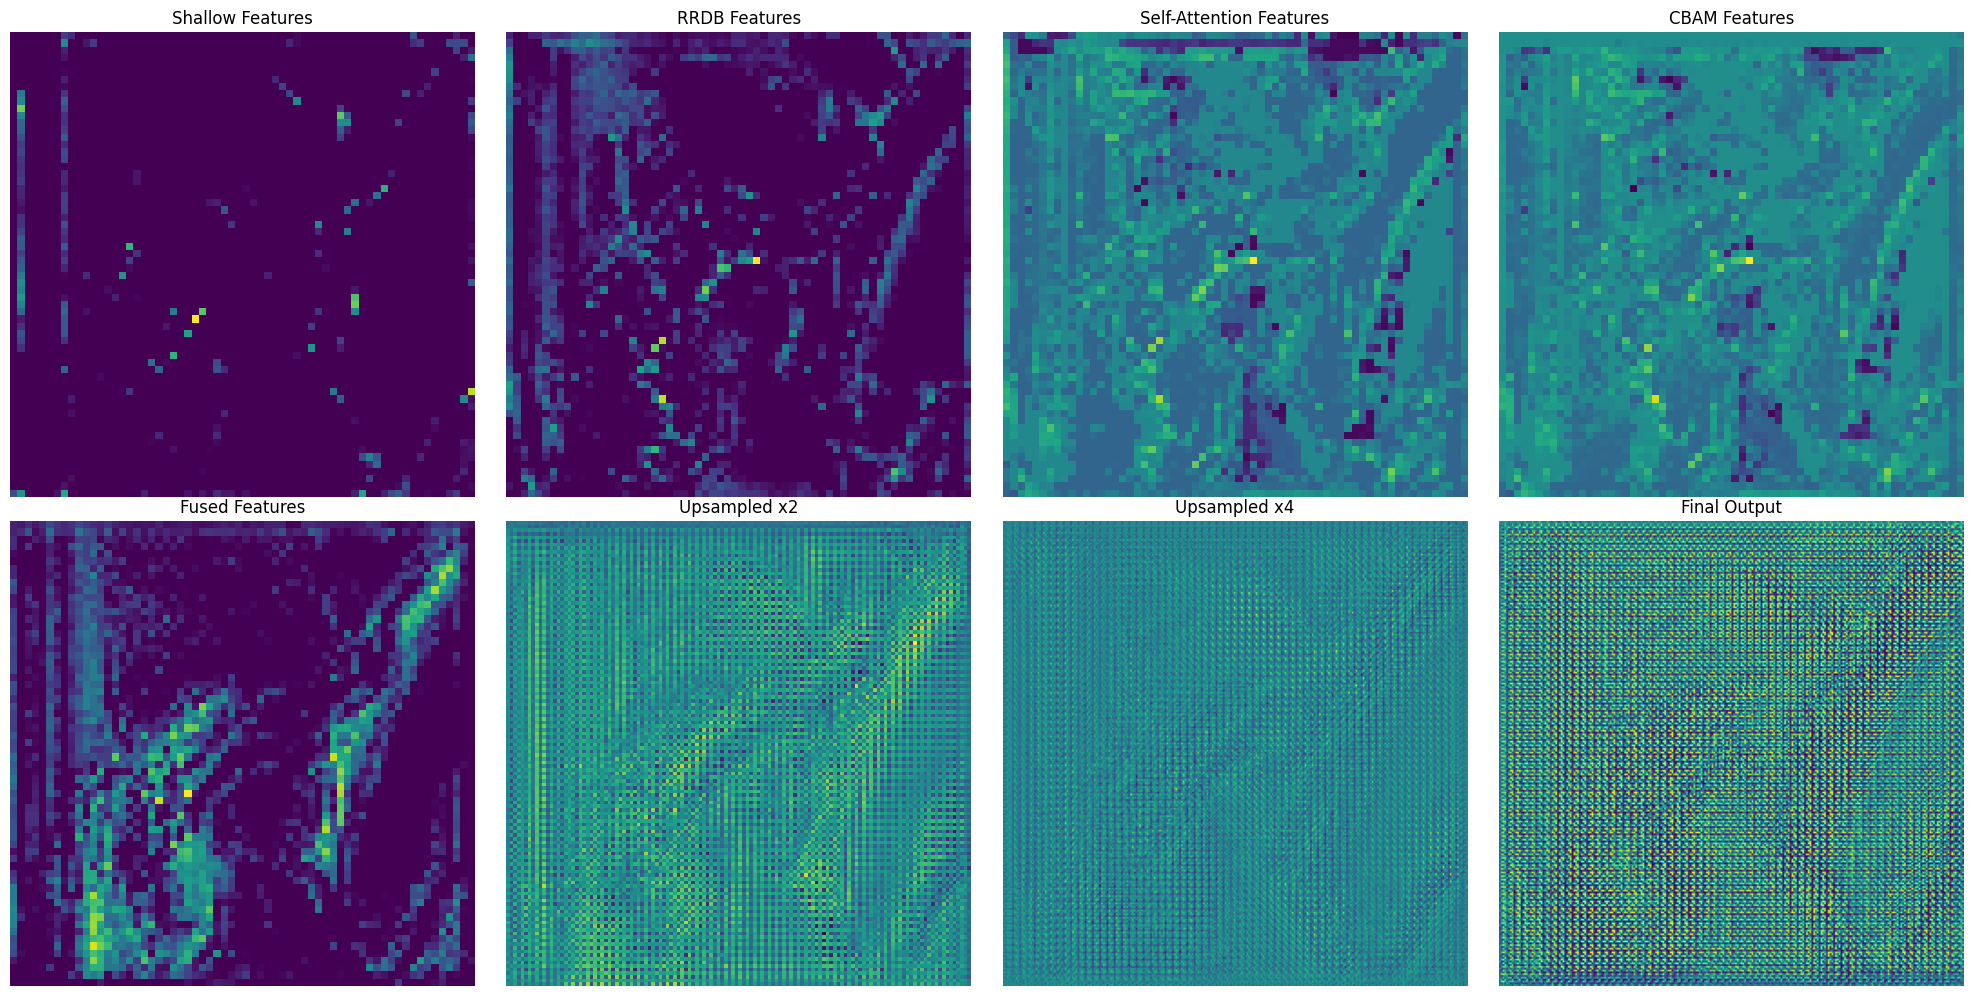

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Input


# CBAM 
def cbam_block(input_tensor, reduction_ratio=8):
    channel = input_tensor.shape[-1]
    avg_pool = layers.GlobalAveragePooling2D()(input_tensor)
    max_pool = layers.GlobalMaxPooling2D()(input_tensor)
    shared_dense_one = layers.Dense(channel // reduction_ratio, activation='relu')
    shared_dense_two = layers.Dense(channel)
    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))
    ca = layers.Add()([avg_out, max_out])
    ca = layers.Activation('sigmoid')(ca)
    ca = layers.Reshape((1, 1, channel))(ca)
    channel_refined = layers.Multiply()([input_tensor, ca])
    avg_pool = tf.reduce_mean(channel_refined, axis=-1, keepdims=True)
    max_pool = tf.reduce_max(channel_refined, axis=-1, keepdims=True)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    sa = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    refined = layers.Multiply()([channel_refined, sa])
    return refined

# Self-Attention Block
def self_attention_2d(x):
    filters = x.shape[-1]
    f = layers.Conv2D(filters // 8, kernel_size=1)(x)
    g = layers.Conv2D(filters // 8, kernel_size=1)(x)
    h = layers.Conv2D(filters, kernel_size=1)(x)
    f_flat = tf.reshape(f, [tf.shape(f)[0], -1, f.shape[-1]])
    g_flat = tf.reshape(g, [tf.shape(g)[0], -1, g.shape[-1]])
    h_flat = tf.reshape(h, [tf.shape(h)[0], -1, h.shape[-1]])
    beta = tf.nn.softmax(tf.matmul(f_flat, g_flat, transpose_b=True), axis=-1)
    o = tf.matmul(beta, h_flat)
    o = tf.reshape(o, tf.shape(x))
    o = layers.Conv2D(filters, 1, padding='same')(o)
    return layers.Add()([x, o])


# Shallow Featur
def shallow_feature_extractor(input_tensor):
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(input_tensor)
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    return x


input_img = Input(shape=(64, 64, 3))
shallow_features = shallow_feature_extractor(input_img)
rrdb_features = layers.Conv2D(64, 3, padding='same', activation='relu')(shallow_features)
attention_features = self_attention_2d(rrdb_features)
cbam_features = cbam_block(attention_features)
fused = layers.Concatenate()([shallow_features, cbam_features])
fused = layers.Conv2D(64, 3, padding='same', activation='relu')(fused)
up1 = layers.Conv2D(256, 3, padding='same')(fused)
up1 = tf.nn.depth_to_space(up1, block_size=2)
up2 = layers.Conv2D(256, 3, padding='same')(up1)
up2 = tf.nn.depth_to_space(up2, block_size=2)
output_img = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(up2)
model = Model(inputs=input_img, outputs=[shallow_features, rrdb_features, attention_features, cbam_features, fused, up1, up2, output_img])


in_img_1 = img_array
intermediate_outputs = model.predict(in_img_1)


titles = [
    "Shallow Features", "RRDB Features", "Self-Attention Features",
    "CBAM Features", "Fused Features", "Upsampled x2", "Upsampled x4", "Final Output"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, ax in enumerate(axes.flat):
    img = intermediate_outputs[i][0, :, :, 0]  
    ax.imshow(img, cmap='viridis')
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()
